In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
import pandas as pd
from sklearn.cluster import DBSCAN

import sys


from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

# from src import Multicolour_Simulation_Functions

# MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from pyS3M import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from pyS3M import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

import pyS3M.HelperFunctions as HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from pyS3M import localise
from pyS3M import postprocess
from pyS3M import render
import pyS3M.DriftCorrectionFunctions as DCF


/tmp/ipykernel_100950/41404898.py:27: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [17]:
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20251127_ATTO565ATTO594/data/2p5pM_10perc561_568LP_1"
image_files = H_F.file_search(image_folder, ".tif", "")
metadata_files = H_F.file_search(image_folder, 'metadata', '')
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])

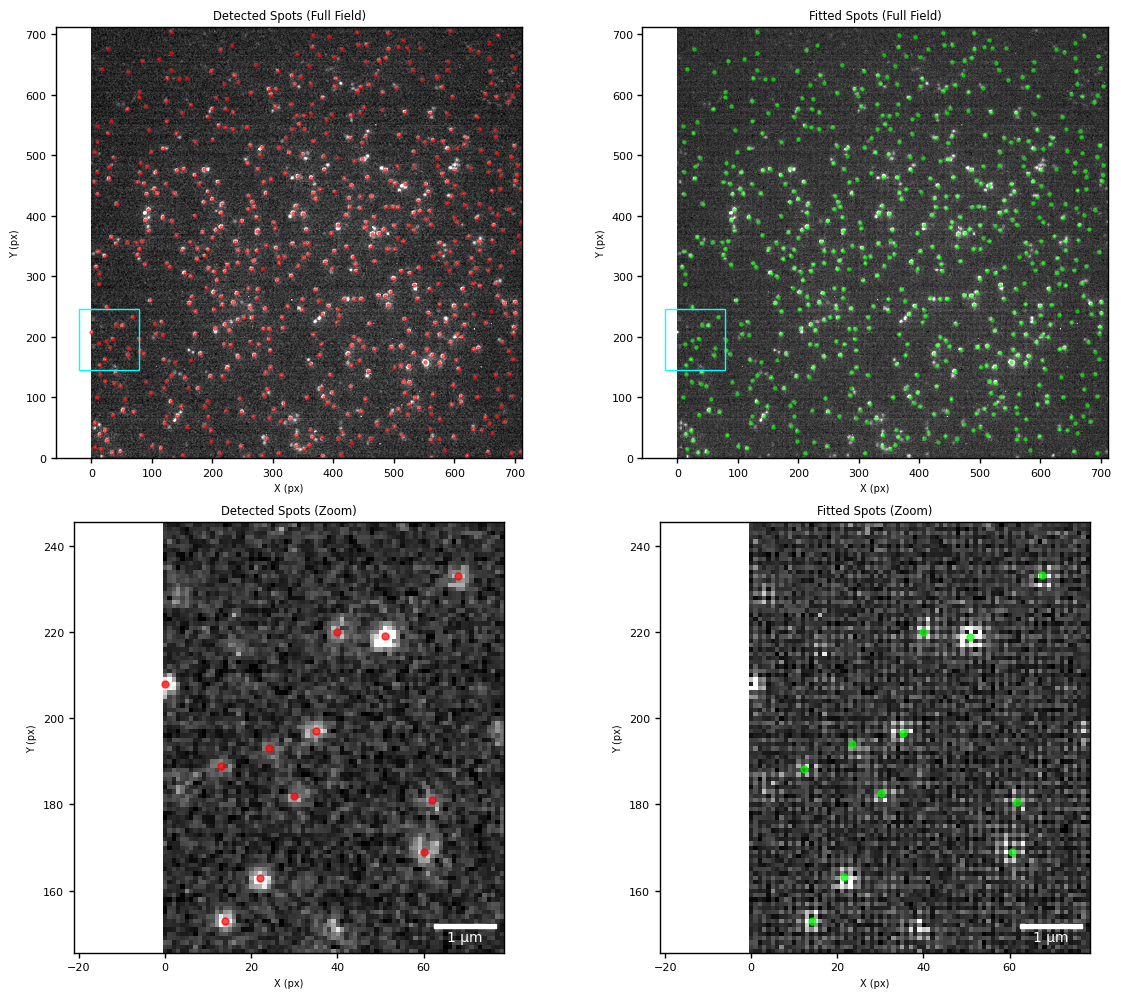

In [18]:
# play around with pfa to find a good parameter
pfa = 1e-3
sigma = 1.5
fraction_true=0.2
peak_wavelength = 0.6
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=pfa, sigma=sigma, fraction_true=fraction_true, frame_index=2, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=peak_wavelength)
plt.show()

In [16]:
SupRes_F.fit_SM_data(
    image_folder,
    smoothing_function,
    gain_map=gain_map,
    offset_map=offset_map,
    variance=variance,
    rqe=rqe,
    read_noise=read_noise,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    sigma=sigma,
    fraction_true=fraction_true,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

Processing file 1/16: 2000 frames in chunks of 1000
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Found 561101 puncta across all chunks                                         ?, ?it/s]
Processing file 2/16: 2000 frames in chunks of 1000                             ?, ?it/s]
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Found 532786 puncta across all chunks                                         ?, ?it/s]
Processing file 3/16: 2000 frames in chunks of 1000                             ?, ?it/s]
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Found 520450 puncta across all chunks                                         ?, ?it/s]
Processing file 4/16: 2000 frames in chunks of 1000                             ?, ?it/s]
  Processing chunk: frames 0-999
  Proc